# Exploración de Datos — Ruido Urbano en Bogotá D.C.

**Objetivo:** Conocer la estructura, calidad y distribución de los datos.

**Datasets:**
- `larrem_ruido_adultos.csv` — Adultos (18–64 años), 2019–2024
- `obs_ruido_adolescentes_.csv` — Adolescentes (11–17 años), 2019–2025

---

## 1. Preparación del entorno

In [1]:
!pip install pandas matplotlib seaborn --quiet


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi': 110,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

COLOR_ADULTOS = '#2A72B5'
COLOR_ADOL    = '#E8622A'

print('Librerías cargadas correctamente.')

Matplotlib is building the font cache; this may take a moment.


Librerías cargadas correctamente.


## 2. Carga de datos

In [3]:
from google.colab import drive
drive.mount('/content/drive')

BASE = "/content/drive/MyDrive/ciencia_de_datos_ii/"

df_adultos = pd.read_csv(BASE + 'larrem_ruido_adultos.csv', encoding='utf-8')
df_adol    = pd.read_csv(BASE + 'obs_ruido_adolescentes_.csv', sep=';', encoding='utf-8-sig')

print(f'Adultos:      {df_adultos.shape[0]:,} filas × {df_adultos.shape[1]} columnas')
print(f'Adolescentes: {df_adol.shape[0]:,} filas × {df_adol.shape[1]} columnas')

ModuleNotFoundError: No module named 'google'

## 3. Estructura de los datos


In [ ]:
print("=== COLUMNAS — ADULTOS ===")
print(df_adultos.columns.tolist())
print()
print("=== COLUMNAS — ADOLESCENTES ===")
print(df_adol.columns.tolist())

=== COLUMNAS — ADULTOS ===
['Año encuesta', 'Localidad', 'Sexo', 'Aseguramiento', 'Estrato', 'Casos de alteración de la salud por exposición a ruido', 'Casos de somnolencia diurna excesiva', 'Casos de alteración de sueño', 'Uso de audífonos', 'Registros']

=== COLUMNAS — ADOLESCENTES ===
['Año', 'LOCALIDAD', 'EDAD', 'Adolescentes encuestados', 'Adolesc_alteraciónensalud', 'Adolesc_somnolenciadiurna', 'Adolesc_usodeAudifonos']


In [ ]:
print("=== ADULTOS ===")
display(df_adultos.head())

=== ADULTOS ===


,Año encuesta,Localidad,Sexo,Aseguramiento,Estrato,Casos de alteración de la salud por exposición a ruido,Casos de somnolencia diurna excesiva,Casos de alteración de sueño,Uso de audífonos,Registros
0,2019,Antonio Nariño,1,Contributivo (EPS),2,1,0,1,2,3
1,2019,Antonio Nariño,1,Contributivo (EPS),3,4,2,9,4,24
2,2019,Antonio Nariño,1,Ninguno,2,0,0,0,0,1
3,2019,Antonio Nariño,1,Ninguno,3,0,0,1,1,5
4,2019,Antonio Nariño,1,Régimen excepcional,3,1,1,2,0,3


In [ ]:
print("=== ADOLESCENTES===")
display(df_adol.head())

=== ADOLESCENTES===


,Año,LOCALIDAD,EDAD,Adolescentes encuestados,Adolesc_alteraciónensalud,Adolesc_somnolenciadiurna,Adolesc_usodeAudifonos
0,2019,Antonio Nariño,11,36,0,0,29
1,2019,Antonio Nariño,12,17,1,0,9
2,2019,Antonio Nariño,13,25,0,0,21
3,2019,Antonio Nariño,14,27,1,0,19
4,2019,Antonio Nariño,15,13,2,0,10


In [ ]:
print("=== TIPOS DE DATOS — ADULTOS ===")
display(df_adultos.dtypes)

=== TIPOS DE DATOS — ADULTOS ===


,0
Año encuesta,int64
Localidad,object
Sexo,int64
Aseguramiento,object
Estrato,int64
Casos de alteración de la salud por exposición a ruido,int64
Casos de somnolencia diurna excesiva,int64
Casos de alteración de sueño,int64
Uso de audífonos,int64
Registros,int64


In [ ]:
print("=== TIPOS DE DATOS — ADOLESCENTES ===")
display(df_adol.dtypes)

=== TIPOS DE DATOS — ADOLESCENTES ===


,0
Año,int64
LOCALIDAD,object
EDAD,int64
Adolescentes encuestados,int64
Adolesc_alteraciónensalud,int64
Adolesc_somnolenciadiurna,int64
Adolesc_usodeAudifonos,int64


## 4. Calidad de los datos

In [ ]:
print("=== VALORES NULOS — ADULTOS ===")
nulos_ad = df_adultos.isnull().sum()
display(nulos_ad[nulos_ad > 0] if nulos_ad.any() else "Sin valores nulos ✓")

=== VALORES NULOS — ADULTOS ===


'Sin valores nulos ✓'

In [ ]:
print("=== VALORES NULOS — ADOLESCENTES ===")
nulos_adol = df_adol.isnull().sum()
display(nulos_adol[nulos_adol > 0] if nulos_adol.any() else "Sin valores nulos ✓")

=== VALORES NULOS — ADOLESCENTES ===


'Sin valores nulos ✓'

In [ ]:
print(f"Duplicados adultos:      {df_adultos.duplicated().sum()}")
print(f"Duplicados adolescentes: {df_adol.duplicated().sum()}")

Duplicados adultos:      0
Duplicados adolescentes: 0


In [ ]:
print("=== ESTADÍSTICAS DESCRIPTIVAS — ADULTOS ===")
display(df_adultos.describe())

=== ESTADÍSTICAS DESCRIPTIVAS — ADULTOS ===


,Año encuesta,Sexo,Estrato,Casos de alteración de la salud por exposición a ruido,Casos de somnolencia diurna excesiva,Casos de alteración de sueño,Uso de audífonos,Registros
count,1637.000000,1637.000000,1637.000000,1637.000000,1637.000000,1637.000000,1637.000000,1637.000000
mean,2021.543067,1.541845,2.527795,2.538180,0.927917,3.572999,2.954184,9.979230
std,1.724307,0.498398,0.974612,4.615594,2.090480,6.145174,4.539932,14.692348
min,2019.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2020.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,1.000000
50%,2022.000000,2.000000,3.000000,1.000000,0.000000,1.000000,1.000000,4.000000
75%,2023.000000,2.000000,3.000000,3.000000,1.000000,4.000000,4.000000,12.000000
max,2024.000000,2.000000,6.000000,46.000000,26.000000,48.000000,34.000000,104.000000


In [ ]:
print("=== ESTADÍSTICAS DESCRIPTIVAS — ADOLESCENTES ===")
display(df_adol.describe())

=== ESTADÍSTICAS DESCRIPTIVAS — ADOLESCENTES ===


,Año,EDAD,Adolescentes encuestados,Adolesc_alteraciónensalud,Adolesc_somnolenciadiurna,Adolesc_usodeAudifonos
count,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000
mean,2022.010638,14.002128,16.538298,2.460638,0.527660,11.600000
std,1.992503,1.996801,11.130441,2.889064,1.017567,7.831125
min,2019.000000,11.000000,1.000000,0.000000,0.000000,0.000000
25%,2020.000000,12.000000,8.750000,0.000000,0.000000,6.000000
50%,2022.000000,14.000000,15.000000,1.000000,0.000000,10.000000
75%,2024.000000,16.000000,22.000000,4.000000,1.000000,15.000000
max,2025.000000,17.000000,65.000000,18.000000,7.000000,46.000000


## 5. Cobertura temporal y geográfica

> ¿Qué años y localidades están cubiertos?

In [ ]:
print("Años — Adultos:     ", sorted(df_adultos['Año encuesta'].unique()))
print("Años — Adolescentes:", sorted(df_adol['Año'].unique()))

Años — Adultos:      [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Años — Adolescentes: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


In [ ]:
locs_adultos = set(df_adultos['Localidad'].unique())
locs_adol    = set(df_adol['LOCALIDAD'].unique())

print(f"Localidades en adultos:      {len(locs_adultos)}")
print(f"Localidades en adolescentes: {len(locs_adol)}")
print(f"En común:                    {len(locs_adultos & locs_adol)}")
print(f"Solo en adultos:             {locs_adultos - locs_adol}")
print(f"Solo en adolescentes:        {locs_adol - locs_adultos}")

Localidades en adultos:      20
Localidades en adolescentes: 20
En común:                    20
Solo en adultos:             set()
Solo en adolescentes:        set()


In [ ]:
# Registros por año — adultos
display(
    df_adultos.groupby('Año encuesta')['Registros']
    .sum()
    .reset_index()
    .rename(columns={'Registros': 'total_registros'})
)

,Año encuesta,total_registros
0,2019,3284
1,2020,2116
2,2021,3055
3,2022,2694
4,2023,2578
5,2024,2609


In [ ]:
# Encuestados por año — adolescentes
display(
    df_adol.groupby('Año')['Adolescentes encuestados']
    .sum()
    .reset_index()
    .rename(columns={'Adolescentes encuestados': 'total_encuestados'})
)

,Año,total_encuestados
0,2019,2365
1,2020,2023
2,2021,2947
3,2022,2406
4,2023,2482
5,2024,2470
6,2025,853


## 6. Distribución por variables categóricas

> ¿Cómo se distribuyen sexo, estrato y régimen de salud?

In [ ]:
# Distribución por sexo (adultos)
display(
    df_adultos.groupby('Sexo')['Registros']
    .sum()
    .reset_index()
    .assign(Sexo=lambda x: x['Sexo'].map({1:'Masculino', 2:'Femenino'}))
    .rename(columns={'Registros': 'total_registros'})
)

,Sexo,total_registros
0,Masculino,4556
1,Femenino,11780


In [ ]:
# Distribución por estrato (adultos)
display(
    df_adultos.groupby('Estrato')['Registros']
    .sum()
    .sort_index()
    .reset_index()
    .rename(columns={'Registros': 'total_registros'})
)

,Estrato,total_registros
0,1,1642
1,2,7292
2,3,6321
3,4,928
4,5,112
5,6,41


In [ ]:
# Distribución por régimen de salud (adultos)
display(
    df_adultos.groupby('Aseguramiento')['Registros']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={'Registros': 'total_registros'})
)

,Aseguramiento,total_registros
0,Contributivo (EPS),8570
1,Subsidiado (EPSS),4048
2,1. Contributivo (EPS),1693
3,2.Subsidiado (EPSS),834
4,Ninguno,668
5,Régimen excepcional,356
6,3. Ninguno,84
7,4. Régimen excepcional,83


## 7. Casos absolutos por localidad

> Antes de calcular prevalencia, ¿cuántos casos hay en bruto?

In [ ]:
print("TOP 10 — Casos absolutos de alteración en salud (adultos):")
display(
    df_adultos.groupby('Localidad')['Casos de alteración de la salud por exposición a ruido']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
    .rename(columns={'Casos de alteración de la salud por exposición a ruido': 'casos_salud'})
)

TOP 10 — Casos absolutos de alteración en salud (adultos):


,Localidad,casos_salud
0,Suba,545
1,Engativá,396
2,Usaquén,280
3,Ciudad Bolívar,268
4,Kennedy,266
5,Fontibón,226
6,Usme,220
7,Barrios Unidos,197
8,Teusaquillo,189
9,Tunjuelito,189


In [ ]:
print("TOP 10 — Casos absolutos de alteración en salud (adolescentes):")
display(
    df_adol.groupby('LOCALIDAD')['Adolesc_alteraciónensalud']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
    .rename(columns={'Adolesc_alteraciónensalud': 'casos_salud'})
)

TOP 10 — Casos absolutos de alteración en salud (adolescentes):


,LOCALIDAD,casos_salud
0,Suba,371
1,Engativá,266
2,Ciudad Bolívar,171
3,Usaquén,165
4,Usme,143
5,Kennedy,127
6,Barrios Unidos,117
7,Bosa,107
8,Fontibón,105
9,Chapinero,101


## 8. Visualizaciones exploratorias


### 8.1 — Registros por localidad (¿la muestra es uniforme?)

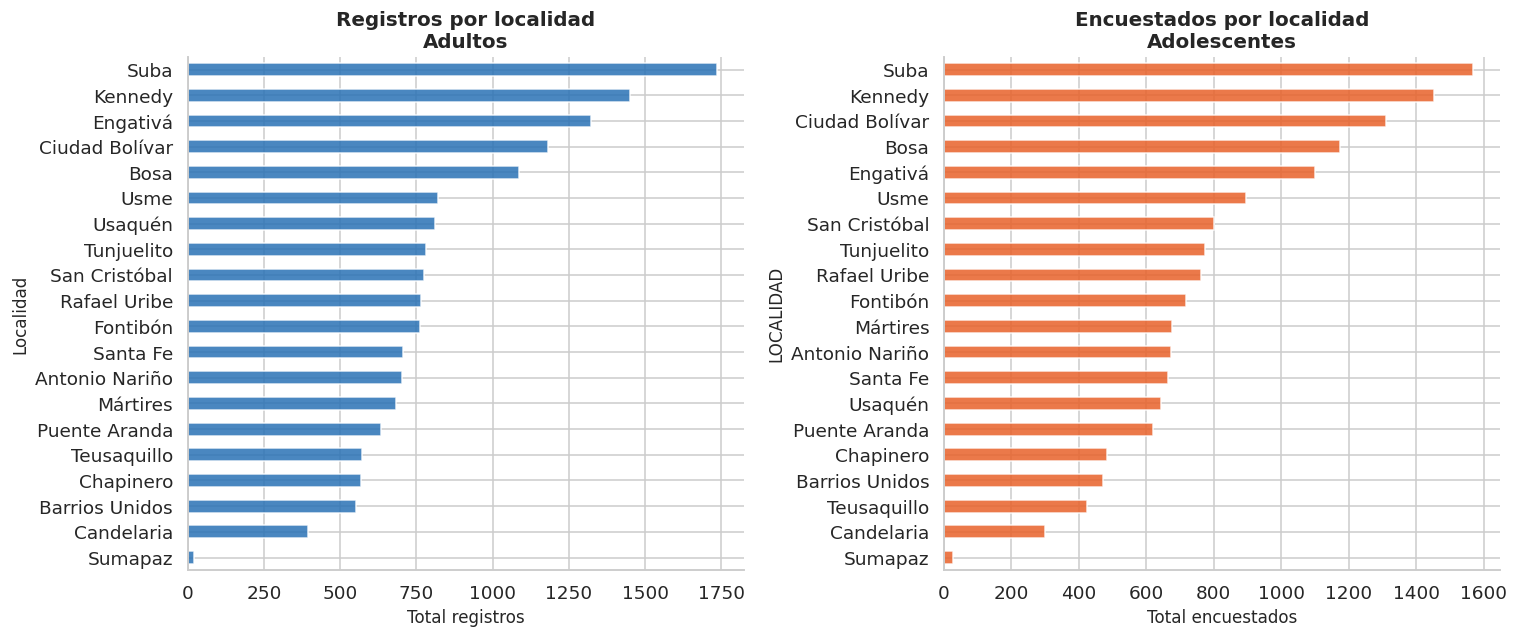

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Adultos
df_adultos.groupby('Localidad')['Registros'].sum().sort_values().plot(
    kind='barh', ax=axes[0], color=COLOR_ADULTOS, alpha=0.85
)
axes[0].set_title('Registros por localidad\nAdultos', fontweight='bold')
axes[0].set_xlabel('Total registros')

# Adolescentes
df_adol.groupby('LOCALIDAD')['Adolescentes encuestados'].sum().sort_values().plot(
    kind='barh', ax=axes[1], color=COLOR_ADOL, alpha=0.85
)
axes[1].set_title('Encuestados por localidad\nAdolescentes', fontweight='bold')
axes[1].set_xlabel('Total encuestados')

sns.despine()
plt.tight_layout()
plt.show()

### 8.2 — Casos totales por año (¿se ve el efecto pandemia 2020?)

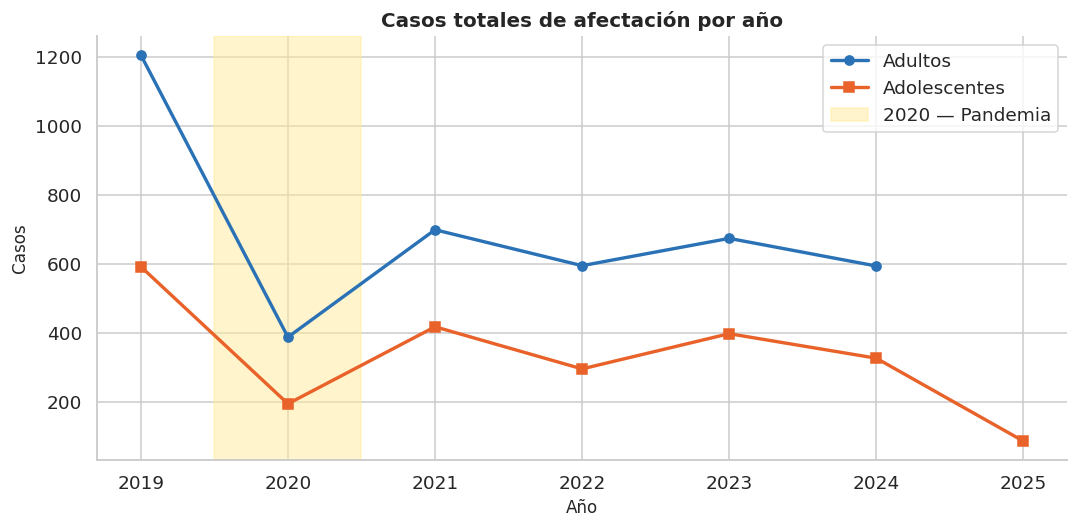

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

df_adultos.groupby('Año encuesta')['Casos de alteración de la salud por exposición a ruido'].sum().plot(
    ax=ax, marker='o', color=COLOR_ADULTOS, linewidth=2.2, label='Adultos'
)
df_adol.groupby('Año')['Adolesc_alteraciónensalud'].sum().plot(
    ax=ax, marker='s', color=COLOR_ADOL, linewidth=2.2, label='Adolescentes'
)

ax.axvspan(2019.5, 2020.5, color='#FFEB99', alpha=0.5, label='2020 — Pandemia')
ax.set_title('Casos totales de afectación por año', fontweight='bold')
ax.set_xlabel('Año')
ax.set_ylabel('Casos')
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()

### 8.3 — Distribución por estrato (¿hay sesgo muestral?)

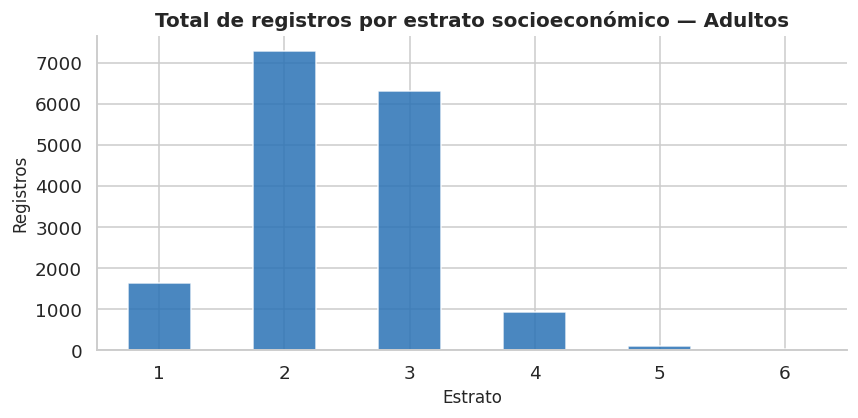

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))

df_adultos.groupby('Estrato')['Registros'].sum().plot(
    kind='bar', ax=ax, color=COLOR_ADULTOS, alpha=0.85, edgecolor='white'
)
ax.set_title('Total de registros por estrato socioeconómico — Adultos', fontweight='bold')
ax.set_xlabel('Estrato')
ax.set_ylabel('Registros')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
sns.despine()
plt.tight_layout()
plt.show()

### 8.4 — Distribución por sexo por año

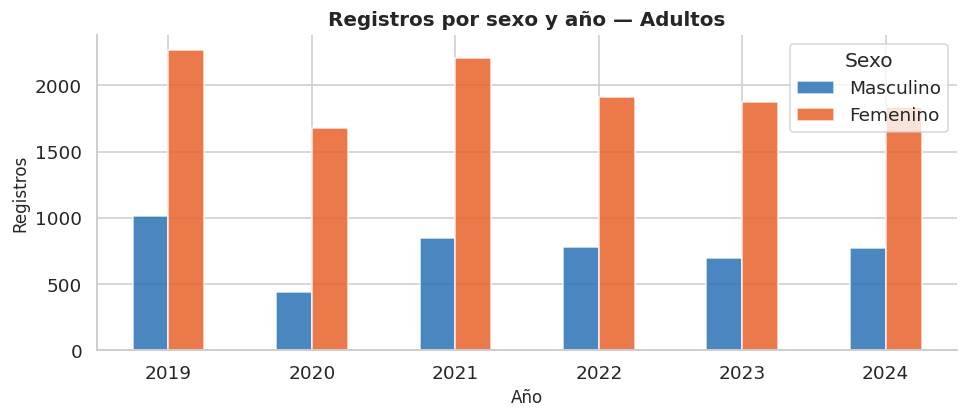

In [ ]:
pivot_sexo = (
    df_adultos.groupby(['Año encuesta', 'Sexo'])['Registros']
    .sum()
    .unstack()
    .rename(columns={1: 'Masculino', 2: 'Femenino'})
)

fig, ax = plt.subplots(figsize=(9, 4))
pivot_sexo.plot(kind='bar', ax=ax, color=[COLOR_ADULTOS, COLOR_ADOL],
                alpha=0.85, edgecolor='white')
ax.set_title('Registros por sexo y año — Adultos', fontweight='bold')
ax.set_xlabel('Año')
ax.set_ylabel('Registros')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title='Sexo')
sns.despine()
plt.tight_layout()
plt.show()

### 8.5 — Top 8 localidades: casos absolutos vs. prevalencia

> Muestra por qué normalizar importa: el ranking puede cambiar.

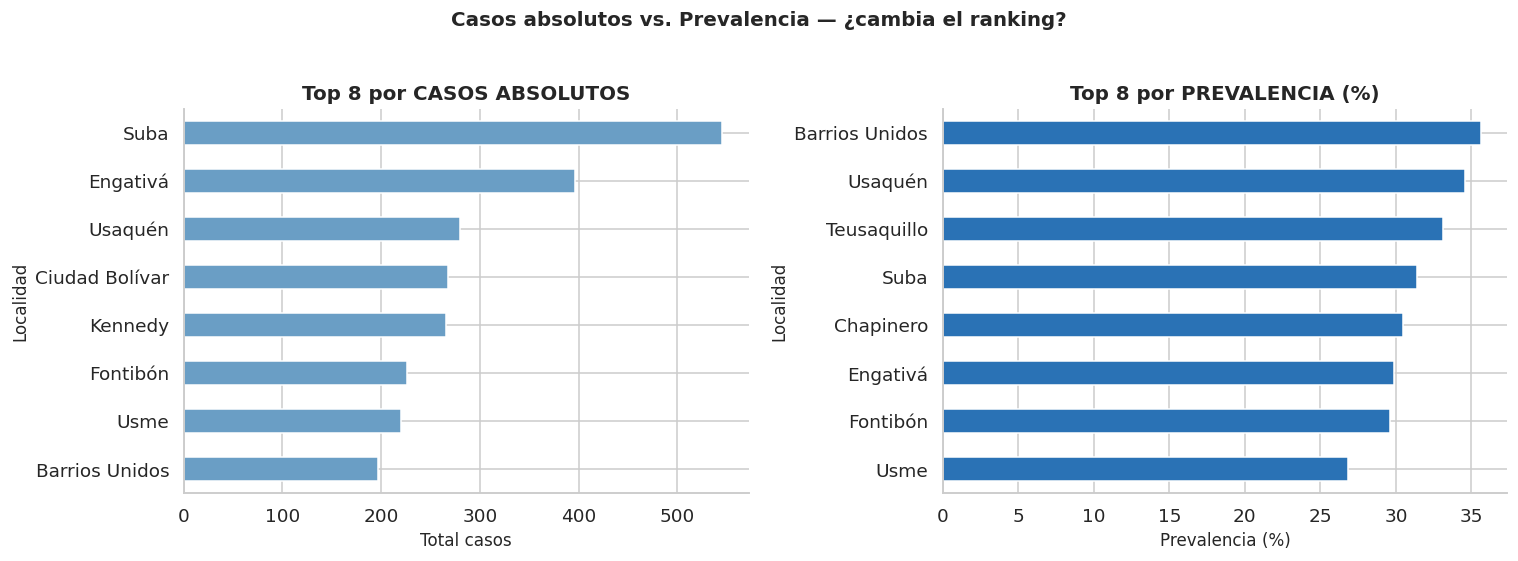


Ranking absolutos: ['Suba', 'Engativá', 'Usaquén', 'Ciudad Bolívar', 'Kennedy', 'Fontibón', 'Usme', 'Barrios Unidos']
Ranking prevalencia: ['Barrios Unidos', 'Usaquén', 'Teusaquillo', 'Suba', 'Chapinero', 'Engativá', 'Fontibón', 'Usme']


In [ ]:
# Calcular ambas métricas
resumen = df_adultos.groupby('Localidad').agg(
    casos_salud=('Casos de alteración de la salud por exposición a ruido', 'sum'),
    registros  =('Registros', 'sum')
).reset_index()
resumen['prevalencia'] = (resumen['casos_salud'] / resumen['registros'] * 100).round(1)

top8_abs  = resumen.nlargest(8, 'casos_salud')['Localidad'].tolist()
top8_prev = resumen.nlargest(8, 'prevalencia')['Localidad'].tolist()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Casos absolutos
r1 = resumen.set_index('Localidad')['casos_salud'].loc[top8_abs].sort_values()
r1.plot(kind='barh', ax=axes[0], color='#6A9EC5', edgecolor='white')
axes[0].set_title('Top 8 por CASOS ABSOLUTOS', fontweight='bold')
axes[0].set_xlabel('Total casos')

# Prevalencia
r2 = resumen.set_index('Localidad')['prevalencia'].loc[top8_prev].sort_values()
r2.plot(kind='barh', ax=axes[1], color=COLOR_ADULTOS, edgecolor='white')
axes[1].set_title('Top 8 por PREVALENCIA (%)', fontweight='bold')
axes[1].set_xlabel('Prevalencia (%)')

sns.despine()
plt.suptitle('Casos absolutos vs. Prevalencia — ¿cambia el ranking?',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\nRanking absolutos:", top8_abs)
print("Ranking prevalencia:", top8_prev)

## 9. Resumen de hallazgos exploratorios

> Completa esta celda después de ejecutar el notebook.

In [ ]:
print("=== RESUMEN RÁPIDO ===")
print(f"Periodo adultos:       {df_adultos['Año encuesta'].min()} – {df_adultos['Año encuesta'].max()}")
print(f"Periodo adolescentes:  {df_adol['Año'].min()} – {df_adol['Año'].max()}")
print(f"Total registros adultos:      {df_adultos['Registros'].sum():,}")
print(f"Total encuestados adolescentes: {df_adol['Adolescentes encuestados'].sum():,}")
print()

# Localidad con más casos absolutos
loc_max_abs = (df_adultos.groupby('Localidad')
               ['Casos de alteración de la salud por exposición a ruido']
               .sum().idxmax())
print(f"Localidad con más casos absolutos (adultos): {loc_max_abs}")

# Año con más casos
anio_max = (df_adultos.groupby('Año encuesta')
            ['Casos de alteración de la salud por exposición a ruido']
            .sum().idxmax())
print(f"Año con más casos (adultos): {anio_max}")

=== RESUMEN RÁPIDO ===
Periodo adultos:       2019 – 2024
Periodo adolescentes:  2019 – 2025
Total registros adultos:      16,336
Total encuestados adolescentes: 15,546

Localidad con más casos absolutos (adultos): Suba
Año con más casos (adultos): 2019
